# Econ 470 HW 5.3
## Claire Hamilton

In [33]:
# Import packages

suppressPackageStartupMessages({
  library(tidyverse)
  library(stargazer)
  library(lmtest)
  library(fixest)
  library(modelsummary)
})

In [34]:
# Import data

final_data <- read_csv("../data/output/final_exp_data.csv", show_col_types = FALSE)

In [35]:
# head(final_data)

# Summarize the Data

## Question 1

In [36]:
# Convert uncomp care to millions

final_data <- final_data %>%
  mutate(uncomp_care_mil = uncomp_care / 1e6)

# Table

uc_table <- final_data %>%
  filter(fyear >= 2011 & fyear <= 2018) %>%
  group_by(fyear) %>%
  summarize(
    mean_uncomp_care = mean(uncomp_care_mil, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(fyear) %>%
  mutate(mean_uncomp_care = round(mean_uncomp_care, 2)) %>%
  rename(
    Year = fyear,
    `Mean Uncompensated Care ($ Millions)` = mean_uncomp_care
  )

uc_table

Year,Mean Uncompensated Care ($ Millions)
<dbl>,<dbl>
2011,34.32
2012,37.02
2013,39.15
2014,36.37
2015,32.94
2016,44.52
2017,40.49
2018,38.03


Mean hospital uncompensated care gradually increased from 2011-2013, then saw a drop in 2014-2015. There is also a slight spike in uncompensated care in 2016-2017. 

## Question 2

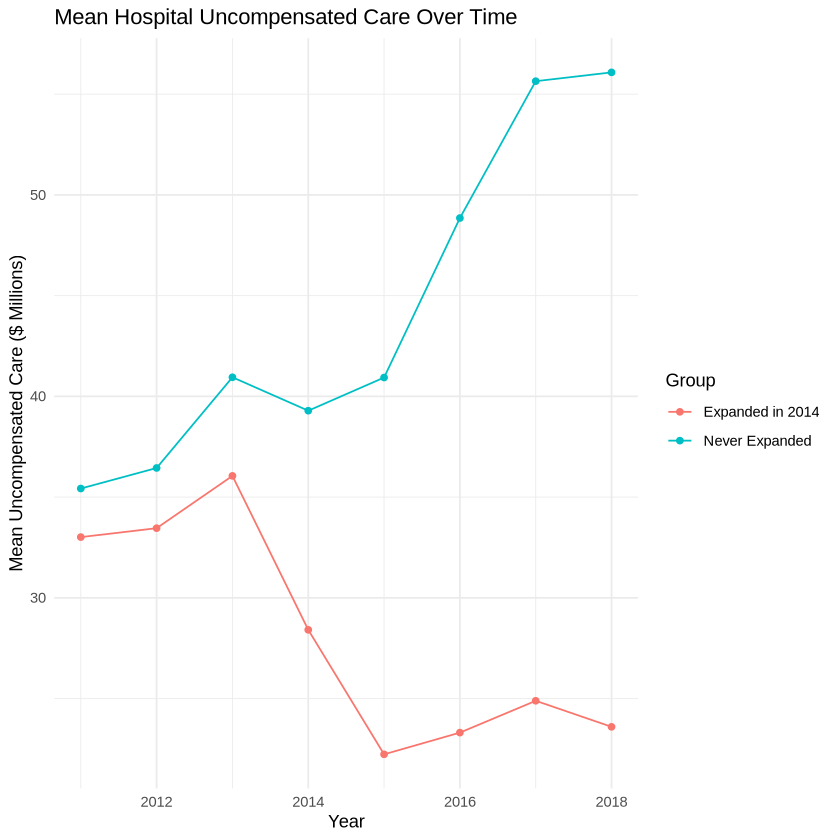

In [37]:
# Create groups

plot_data <- final_data %>%
  filter(fyear >= 2011 & fyear <= 2018) %>%
  filter(
    exp_year == 2014 | is.na(exp_year)
  ) %>%
  filter(uncomp_care_mil < 500) %>%
  mutate(
    expansion_group = case_when(
      exp_year == 2014 ~ "Expanded in 2014",
      is.na(exp_year)  ~ "Never Expanded"
    ),
    uncomp_care_mil = uncomp_care / 1e6
  )

# Calculate mean

plot_summary <- plot_data %>%
  group_by(fyear, expansion_group) %>%
  summarize(
    mean_uc = mean(uncomp_care_mil, na.rm = TRUE),
    .groups = "drop"
  )

# Table

ggplot(plot_summary, aes(x = fyear, y = mean_uc, color = expansion_group)) +
  geom_line() +
  geom_point() +
  labs(
    x = "Year",
    y = "Mean Uncompensated Care ($ Millions)",
    color = "Group",
    title = "Mean Hospital Uncompensated Care Over Time"
  ) +
  theme_minimal()

The graph does suggest a potential treatment effect, as uncompensated care declined starting in 2014 for the expansion states, while it increased substantially for non-expansion states. This suggests that Medicaid expansion is associated with a decrease in hospital uncompensated care. 

## Question 3

In [38]:
dd_data <- final_data %>%
  filter(fyear %in% c(2012, 2015)) %>%
  filter(exp_year == 2014 | is.na(exp_year)) %>%
  mutate(
    group = case_when(
      exp_year == 2014 ~ "Expansion (2014)",
      is.na(exp_year)  ~ "Non-Expansion"
    ),
    uncomp_care_mil = uncomp_care / 1e6
  ) %>%
  filter(uncomp_care_mil < 1400) 

dd_table <- dd_data %>%
  group_by(group, fyear) %>%
  summarize(
    mean_uc = mean(uncomp_care_mil, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(mean_uc = round(mean_uc, 2))

dd_table2 <- dd_table %>%
  pivot_wider(
    names_from = fyear,
    values_from = mean_uc
  ) %>%
  rename(
    `2012 (Pre)` = `2012`,
    `2015 (Post)` = `2015`,
    `Group` = `group`
  )

dd_table2

Group,2012 (Pre),2015 (Post)
<chr>,<dbl>,<dbl>
Expansion (2014),35.03,22.23
Non-Expansion,43.49,45.62


## Question 4

My results show that states that expanded Medicaid in 2014 saw substantial declines in uncompensated care, while states that never expanded saw large increases in uncompensated care from 2014 to 2018. Medicaid expansion as part of the Affordable Care Act increased access to Medicaid, so states that expanded likely had far fewer uninsured patients. Thus, since more people were covered by Medicaid in states that expanded in 2014, these states saw declines in uncompensated care. 

# Estimate ATEs

## Question 5

In [47]:
# Filter / clean data 

reg.dat <- final_data %>%
  filter(uncomp_care > 0, exp_year == 2014 | is.na(exp_year)) %>%
  mutate(
    expand_ever = case_when(
      exp_year == 2014 ~ 1,
      is.na(exp_year) ~ 0
    ),
    post = ifelse(fyear >= 2014, 1, 0),
    treat = post * expand_ever,
    uncomp_care_m = uncomp_care / 1e6
  ) %>%
  filter(!is.na(uncomp_care_m)) %>%
  filter(uncomp_care_mil < 450) 

# Regression

dd.uc.reg <- lm(uncomp_care_m ~ post + expand_ever + post * expand_ever, data = reg.dat)

# Table

modelsummary(
  dd.uc.reg,
  output = "markdown",
  coef_map = c(
    "post" = "Post",
    "expand_ever" = "Expansion State",
    "post:expand_ever" = "Post × Expansion"
  ),
  statistic = "({std.error})",
  stars = TRUE,
  gof_omit = "IC|Log|Adj|RMSE",
  title = "DD Effect of Medicaid Expansion on Uncompensated Care"
)



Table: DD Effect of Medicaid Expansion on Uncompensated Care

|                  |     (1)    | 
|:-----------------|-----------:|
| Post             |  14.195*** | 
|                  |   (1.475)  | 
| Expansion State  |   -3.474*  | 
|                  |   (1.511)  | 
| Post × Expansion | -22.629*** | 
|                  |   (1.858)  | 
| Num.Obs.         |    16903   | 
| R2               |    0.034   | 
| F                |   196.072  | 

__Note:__
^^ + p < 0.1, * p < 0.05, ** p < 0.01, *** p < 0.001

The DD estimate of the effect of Medicaid expansion on hospital uncompensated care is around -22.6 million dollars. This indicates that, after 2014, hospitals in expansion states had a reduction in uncompensated care of about -22.6 million compared to hospitals in non-expansion states.

## Question 6

In [40]:
# Run TWFE model 

m.twfe <- feols(
  uncomp_care_m ~ treat | provider_number + fyear,
  data = reg.dat,
  cluster = ~ state
)

modelsummary(
  m.twfe,
  output = "markdown",
  coef_map = c("treat" = "Medicaid Expansion Effect"),
  statistic = "({std.error})",
  stars = TRUE,
  gof_omit = "IC|Log|Adj|Within|RMSE",
  title = "Effect of Medicaid Expansion on Uncompensated Care (TWFE)"
)



Table: Effect of Medicaid Expansion on Uncompensated Care (TWFE)

|                           |     (1)    | 
|:--------------------------|-----------:|
| Medicaid Expansion Effect | -26.853*** | 
|                           |   (4.129)  | 
| Num.Obs.                  |    16903   | 
| R2                        |    0.838   | 
| Std.Errors                |  by: state | 
| FE: provider_number       |      X     | 
| FE: fyear                 |      X     | 

__Note:__
^^ + p < 0.1, * p < 0.05, ** p < 0.01, *** p < 0.001

When including hospital and year fixed effects, the estimated effect of Medicaid expansion on uncompensated care is approximately −26.8 million dollars. This is close to the estimate from Question 5 (−$22.6 million), showing the results are similar even after adjusting for differences between hospitals and changes over time. Overall, both models suggest that Medicaid expansion substantially reduced hospital uncompensated care.

## Question 7

In [48]:
reg.dat.full <- final_data %>%
  mutate(
    expand_ever = ifelse(!is.na(exp_year), 1, 0),
    post = ifelse(fyear >= exp_year & expand_ever == 1, 1, 0),
    treat = post,
    uncomp_care_m = uncomp_care / 1e6
  ) %>%
  filter(!is.na(uncomp_care_m)) %>%
  filter(uncomp_care_m < 550) 

m.twfe.full <- feols(
  uncomp_care_m ~ treat | provider_number + fyear,
  data = reg.dat.full,
  cluster = ~ state
)

modelsummary(
  m.twfe.full,
  output = "markdown",
  coef_map = c("treat" = "Medicaid Expansion Effect"),
  statistic = "({std.error})",
  stars = TRUE,
  gof_omit = "IC|Log|Adj|Within|RMSE",
  title = "Effect of Medicaid Expansion on Uncompensated Care (All States)"
)



Table: Effect of Medicaid Expansion on Uncompensated Care (All States)

|                           |     (1)    | 
|:--------------------------|-----------:|
| Medicaid Expansion Effect | -22.508*** | 
|                           |   (4.072)  | 
| Num.Obs.                  |    22852   | 
| R2                        |    0.846   | 
| Std.Errors                |  by: state | 
| FE: provider_number       |      X     | 
| FE: fyear                 |      X     | 

__Note:__
^^ + p < 0.1, * p < 0.05, ** p < 0.01, *** p < 0.001

When including all states, the estimated effect of Medicaid expansion is about −22.5 million dollars, which is smaller in magnitude but similar to the estimate from Question 6 (−26.8 million dollars). The results are different because the control group now includes states that expanded later, so those states would then look more like expansion states. This reduces the difference between the treated and control groups.

## Question 8

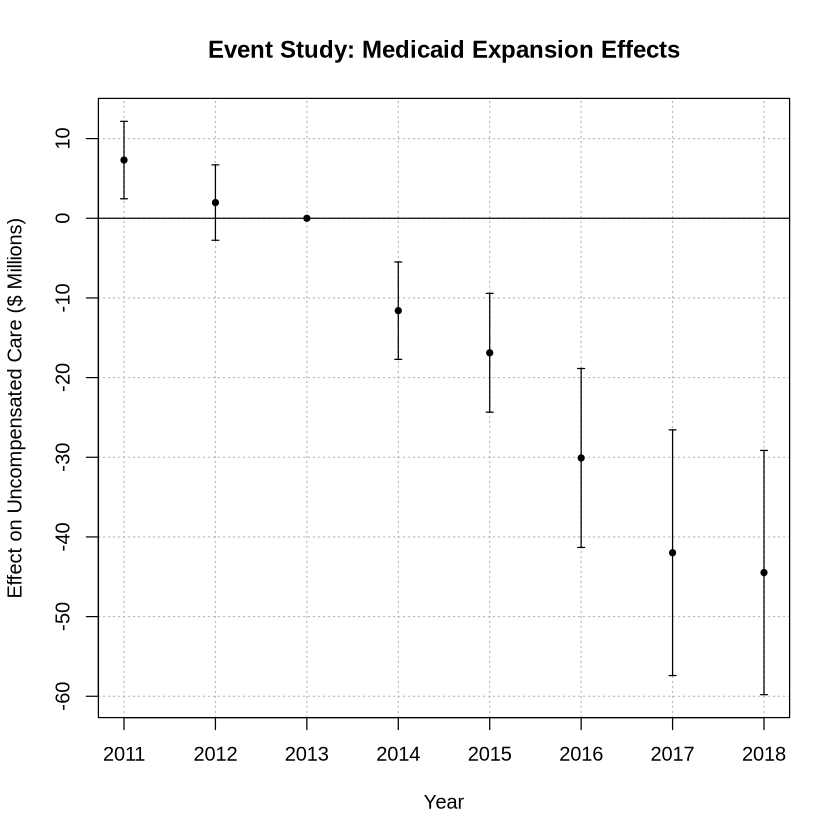

In [42]:
reg.dat <- final_data %>%
  filter(exp_year == 2014 | is.na(exp_year)) %>%
  filter(fyear <= 2018) %>%
  mutate(
    expand_ever = ifelse(!is.na(exp_year) & exp_year == 2014, 1, 0),
    uncomp_care_m = uncomp_care / 1e6
  ) %>%
  filter(!is.na(uncomp_care_m)) 

mod.twfe <- feols(
  uncomp_care_m ~ i(fyear, expand_ever, ref = 2013) | provider_number + fyear,
  data = reg.dat,
  cluster = ~ state
)

iplot(mod.twfe,
      xlab = "Year",
      ylab = "Effect on Uncompensated Care ($ Millions)",
      main = "Event Study: Medicaid Expansion Effects",
      ref.line = 0)

## Question 9

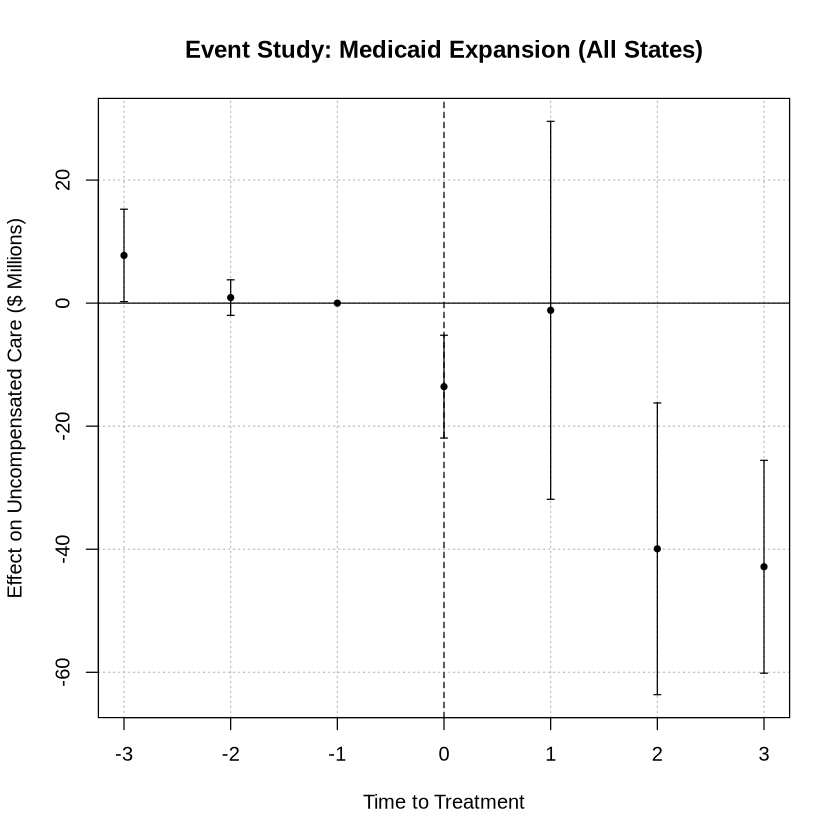

In [43]:
# Create event time variable

reg.dat.full <- final_data %>%
  filter(!is.na(medicaid_exp_status)) %>%
  mutate(
    expand_ever = ifelse(!is.na(exp_year), 1, 0),
    time_to_treat = ifelse(expand_ever == 1, fyear - exp_year, 0)
  )

# Bin endpoints

reg.dat.full <- reg.dat.full %>%
  mutate(
    time_to_treat = ifelse(time_to_treat <= -3, -3, time_to_treat),
    time_to_treat = ifelse(time_to_treat >= 3, 3, time_to_treat),
    uncomp_care_m = uncomp_care / 1e6
  ) %>%
  filter(!is.na(uncomp_care_m))

# Run and plot

mod.twfe.full <- feols(
  uncomp_care_m ~ i(time_to_treat, expand_ever, ref = -1) | provider_number + fyear,
  data = reg.dat.full,
  cluster = ~ state
)

iplot(mod.twfe.full,
      xlab = "Time to Treatment",
      ylab = "Effect on Uncompensated Care ($ Millions)",
      main = "Event Study: Medicaid Expansion (All States)",
      ref.line = 0)

## Question 10

Medicaid expansion is associated with a large and statistically significant decrease in hospital uncompensated care, around 22–27 million dollars per hospital. The event study shows clear declines after expansion, though the pre-treatment confidence intervals do not all include zero (specifically 2011 in the event study with common treatment timing). This raises minor concerns about parallel trends, however it is only 2011 that does not include zero. A limitation of the TWFE approach is that it uses states that expand later as controls, which can affect the accuracy of the estimated effect because these states could be fundamentally different from non-expansion states. 